In [8]:
import pyccl as ccl
print(f"I am using pyccl version {ccl.__version__}")
from scripts.data_vectors import DataVectors
from scripts.presets import Presets

import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

import matplotlib
font = {'size'   : 20}
matplotlib.rc('font', **font)

I am using pyccl version 3.1.2


In this notebook we range over different values of magnification for "forbidden" combinations of bins for 3x2pt analyses. Before we do this, we have to implement the magnification bias option for the wrappers in the `DataVector` files. So, this notebook in split into two major parts: 

1. Testing the magnification implementation with the non-forbidden pairs
2. Testing the magnification implementation with the forbidden pairs

In [2]:
def interpolate_magbias(magbias_file_pth, maglims_file_pth, maglim):

    magbias_vals_perzbin = np.load(magbias_file_pth)[:,:,0].T
    maglims = np.load(maglims_file_pth)

    alphas = []
    for zbin, magbias_vals in enumerate(magbias_vals_perzbin):
        alpha_z = interp1d(maglims, magbias_vals)
        alphas += [alpha_z(maglim)]

    return alphas

## Magnification Implementation Tests

In [3]:
presetsy1 = Presets(forecast_year='1')
presetsy10 = Presets(forecast_year='10')

dvy1 = DataVectors(presetsy1)
dvy10 = DataVectors(presetsy10)

In [4]:
magbias_y1 = interpolate_magbias('scripts/magbias/magbias_forecast_values_y1.npy',
                                 'scripts/magbias/magbias_maglims.npy',
                                 presetsy1.lens_parameters['limiting_magnitude']
                                )

magbias_y10 = interpolate_magbias('scripts/magbias/magbias_forecast_values_y10.npy',
                                  'scripts/magbias/magbias_maglims.npy',
                                  presetsy1.lens_parameters['limiting_magnitude']
                                 )

#### Non-forbidden Pairs

In [5]:
ggl_y1 = dvy1.galaxy_galaxy_lensing_cls(magbias=magbias_y1)
ggl_y10 = dvy10.galaxy_galaxy_lensing_cls(magbias=magbias_y10)

ggl_y1_nomagbias = dvy1.galaxy_galaxy_lensing_cls(magbias=False)
ggl_y10_nomagbias = dvy10.galaxy_galaxy_lensing_cls(magbias=False)

Data saved to data_output/angular_power_spectra/galaxy_galaxy_lensing_correlations_y1.npy
Data saved to data_output/angular_power_spectra/galaxy_galaxy_lensing_cls_y1_zmax5_zres6000_ccl_v3.1.2.npy
Data saved to data_output/angular_power_spectra/galaxy_galaxy_lensing_correlations_y10.npy
Data saved to data_output/angular_power_spectra/galaxy_galaxy_lensing_cls_y10_zmax5_zres6000_ccl_v3.1.2.npy
Data saved to data_output/angular_power_spectra/galaxy_galaxy_lensing_correlations_y1.npy
Data saved to data_output/angular_power_spectra/galaxy_galaxy_lensing_cls_y1_zmax5_zres6000_ccl_v3.1.2.npy
Data saved to data_output/angular_power_spectra/galaxy_galaxy_lensing_correlations_y10.npy
Data saved to data_output/angular_power_spectra/galaxy_galaxy_lensing_cls_y10_zmax5_zres6000_ccl_v3.1.2.npy


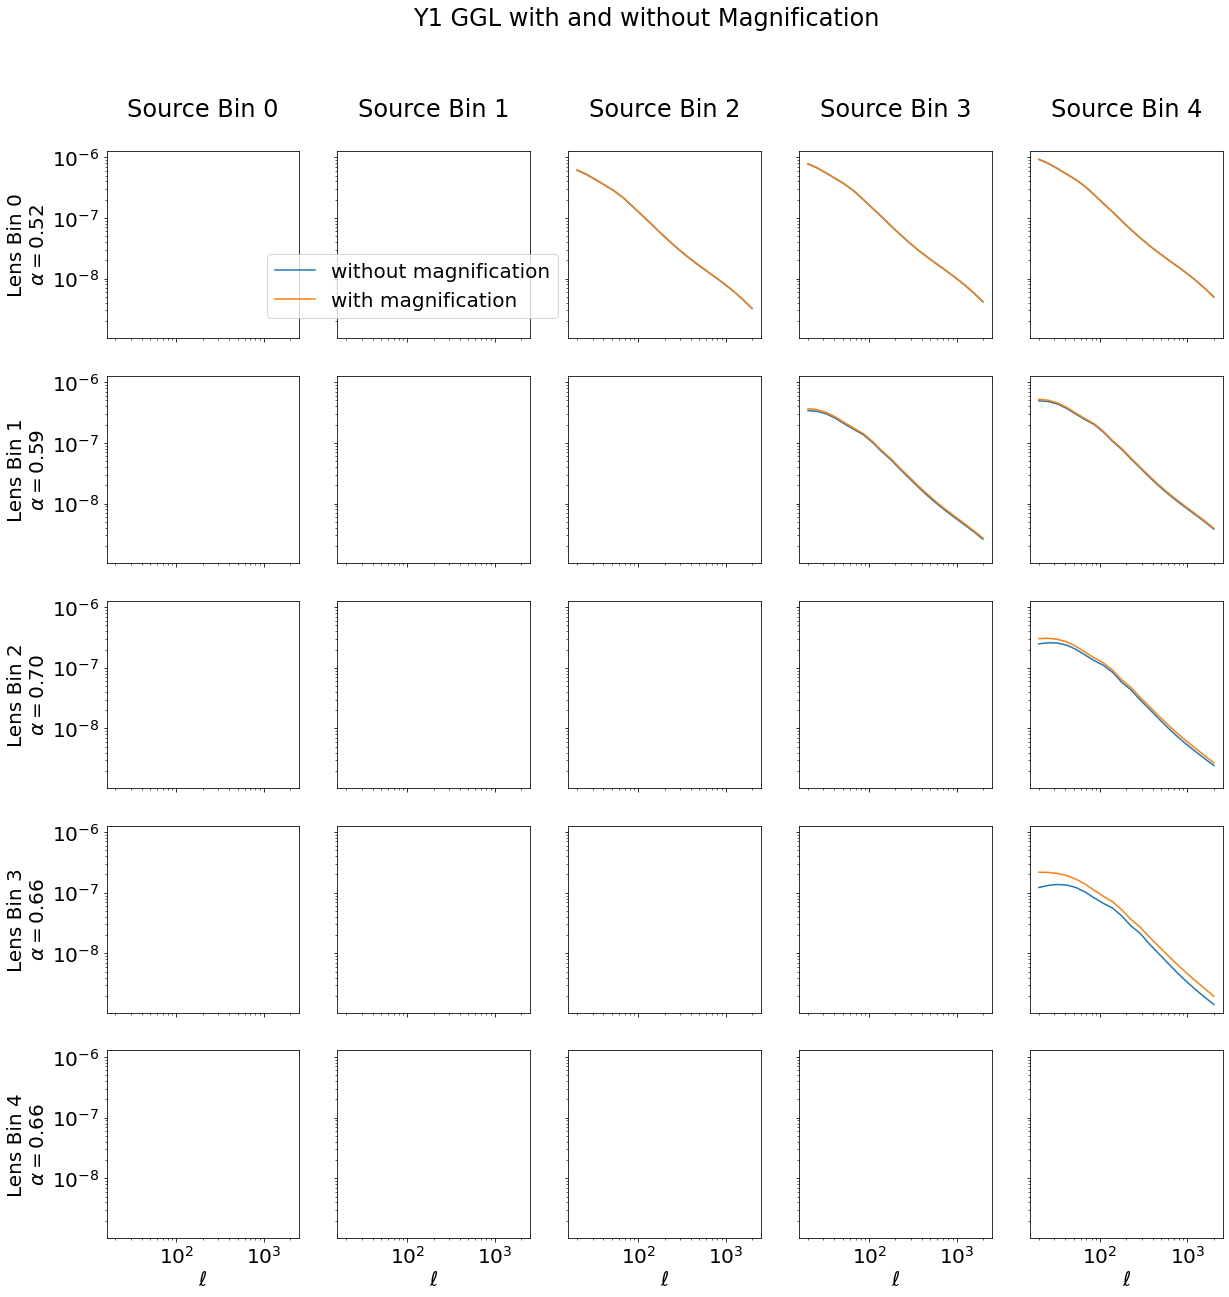

In [9]:
fig, axs = plt.subplots(5,5, figsize=(20,20), sharey=True, sharex=True)

for i,(lensbin, sourcebin) in enumerate(dvy1.get_correlation_pairs()["galaxy_galaxy_lensing"]):
    
    axs[lensbin, sourcebin].plot(dvy1.ells, ggl_y1_nomagbias.T[i], label=r"without magnification")
    axs[lensbin, sourcebin].plot(dvy1.ells, ggl_y1.T[i], 
                                 label=r"with magnification")

    axs[lensbin, sourcebin].set_yscale('log')
    axs[lensbin, sourcebin].set_xscale('log')
    

[a.set_ylabel('Lens Bin %i\n'%i+r"$\alpha = $"+"%.02f"%magbias_y10[i], fontsize=20) 
 for i,a in enumerate(axs[:,0])]
[a.set_xlabel(r'$\ell$') for i,a in enumerate(axs[-1])]
[a.set_title('Source Bin %i\n'%i ) for i,a in enumerate(axs[0])]

axs[0,2].legend(bbox_to_anchor=(0,0.5))
plt.suptitle('Y1 GGL with and without Magnification')

plt.show()

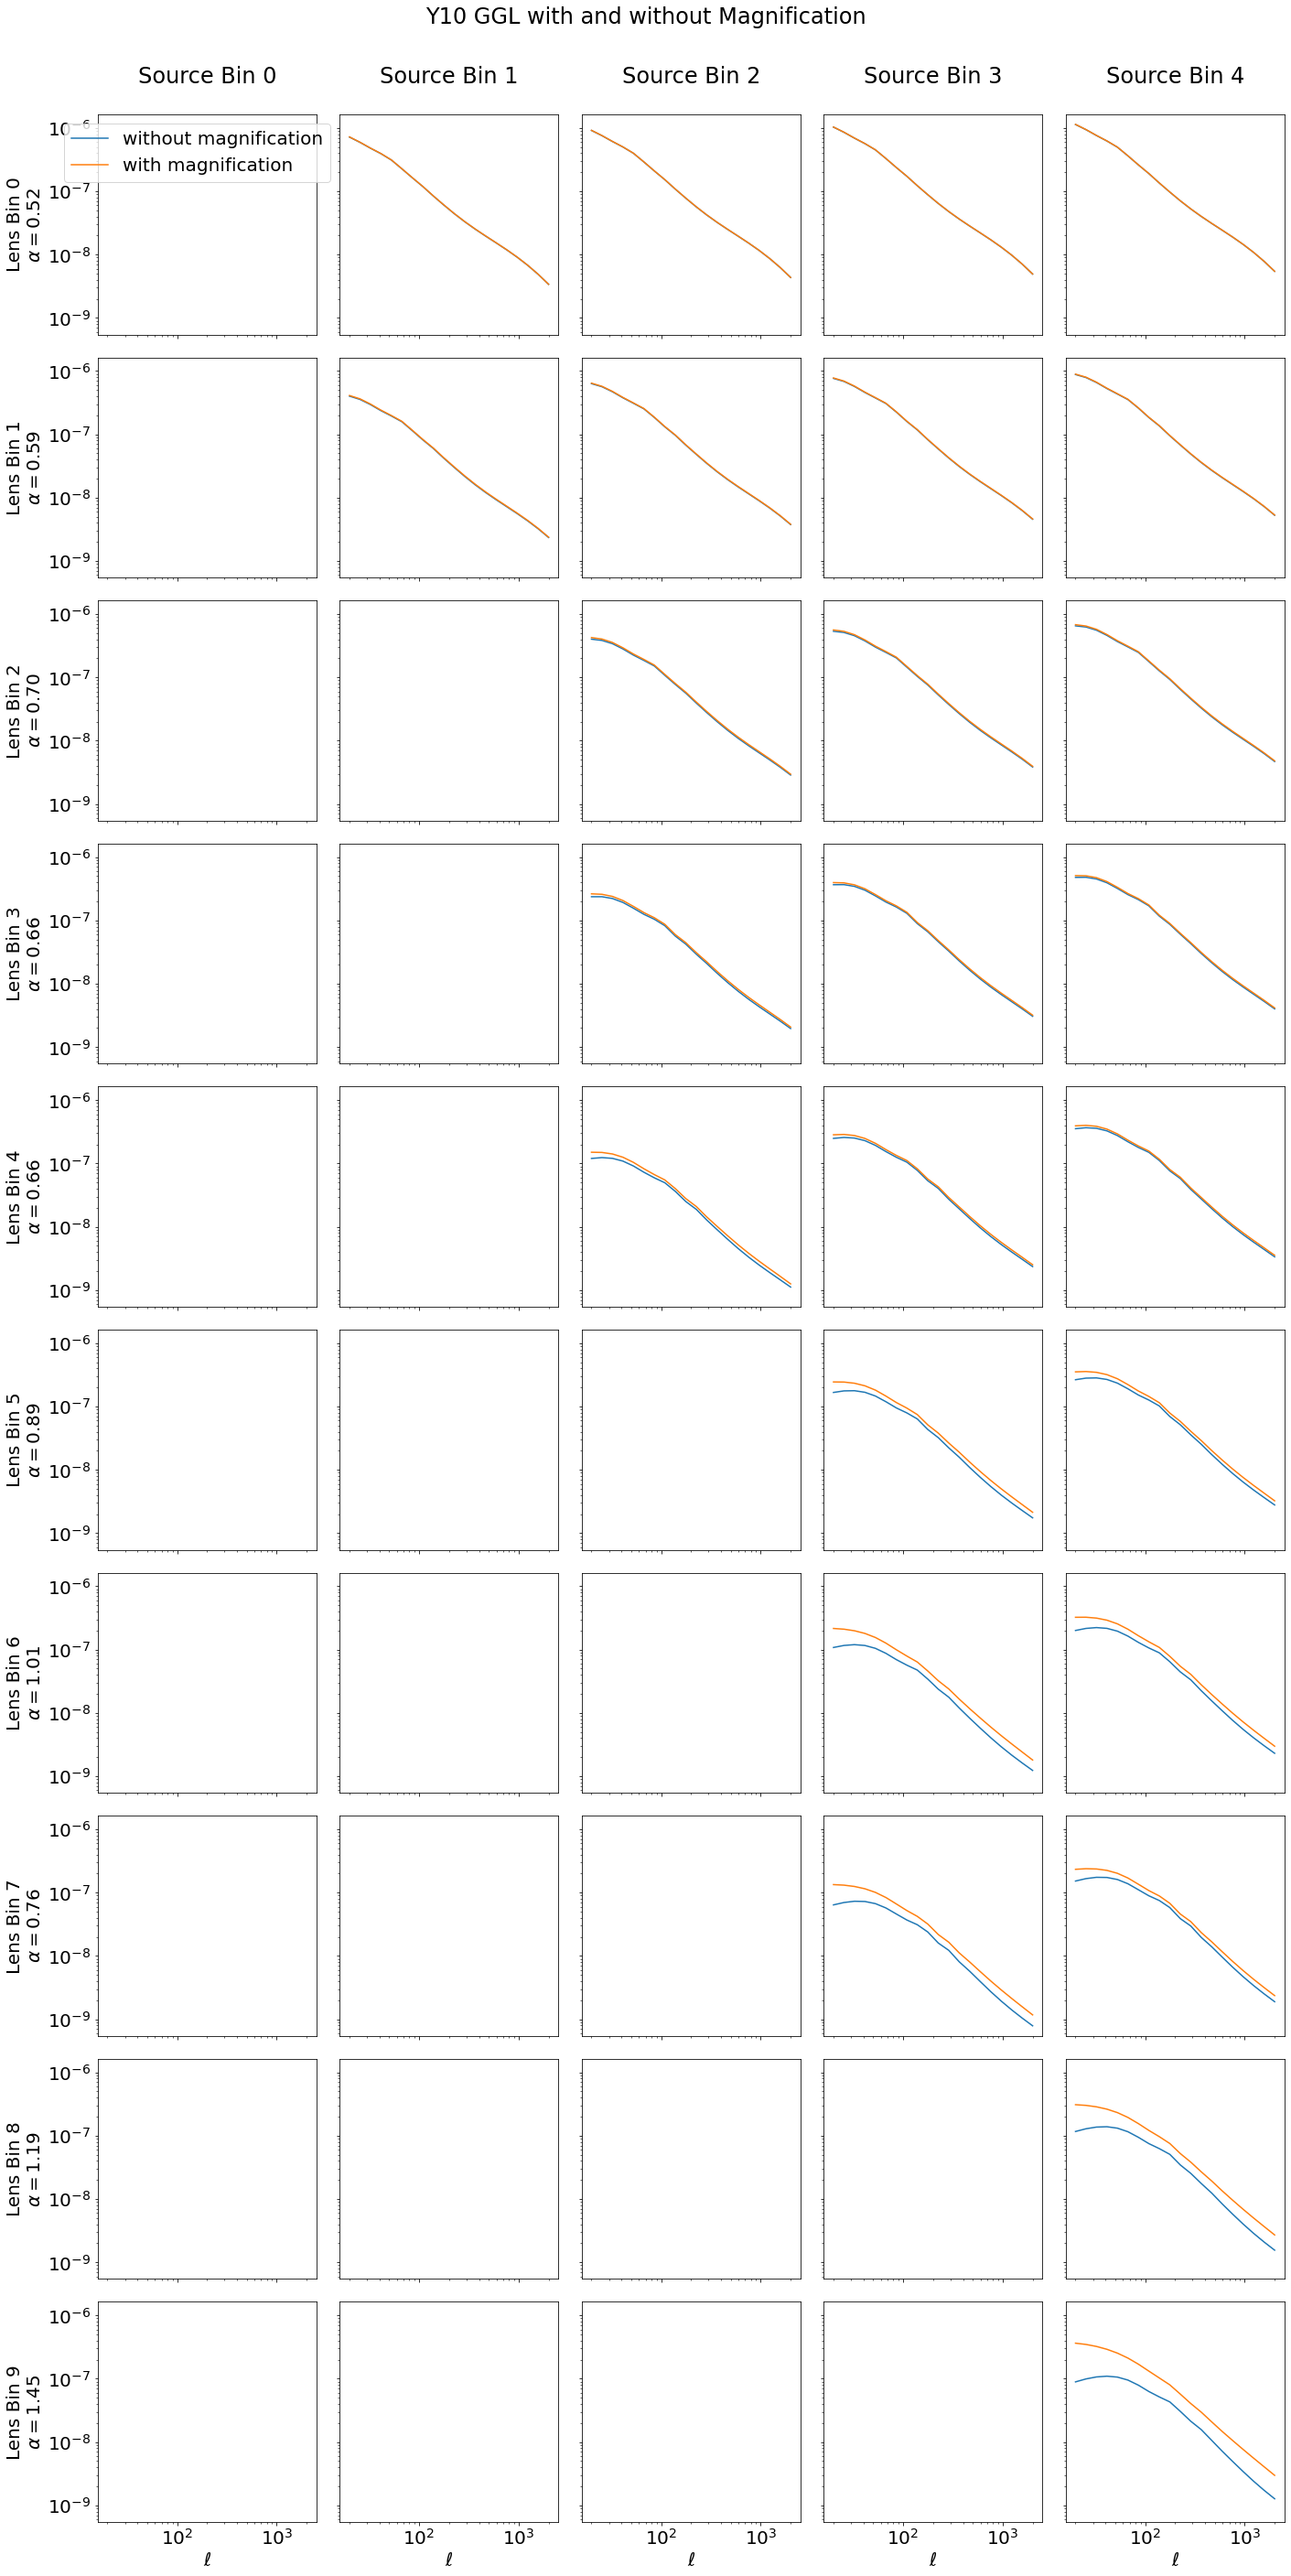

In [10]:
fig, axs = plt.subplots(10,5, figsize=(20,40), sharey=True, sharex=True)

for i,(lensbin, sourcebin) in enumerate(dvy10.get_correlation_pairs()["galaxy_galaxy_lensing"]):
    
    axs[lensbin, sourcebin].plot(dvy10.ells, ggl_y10_nomagbias.T[i], label=r"without magnification")
    axs[lensbin, sourcebin].plot(dvy10.ells, ggl_y10.T[i], 
                                 label=r"with magnification")

    axs[lensbin, sourcebin].set_yscale('log')
    axs[lensbin, sourcebin].set_xscale('log')
    

[a.set_ylabel('Lens Bin %i\n'%i+r"$\alpha = $"+"%.02f"%magbias_y10[i], fontsize=20) 
 for i,a in enumerate(axs[:,0])]
[a.set_xlabel(r'$\ell$') for i,a in enumerate(axs[-1])]
[a.set_title('Source Bin %i\n'%i) for i,a in enumerate(axs[0])]
plt.suptitle('Y10 GGL with and without Magnification\n\n')

fig.tight_layout()

axs[0,1].legend(bbox_to_anchor=(0,1))

plt.show()

#### Magnification with Forbidden Pairs

In [11]:
ggl_y1 = dvy1.galaxy_galaxy_lensing_cls(magbias=magbias_y1, include_all_correlations=True)
ggl_y10 = dvy10.galaxy_galaxy_lensing_cls(magbias=magbias_y10, include_all_correlations=True)

ggl_y1_nomagbias = dvy1.galaxy_galaxy_lensing_cls(magbias=False, include_all_correlations=True)
ggl_y10_nomagbias = dvy10.galaxy_galaxy_lensing_cls(magbias=False, include_all_correlations=True)

Data saved to data_output/angular_power_spectra/galaxy_galaxy_lensing_correlations_all_y1.npy
Data saved to data_output/angular_power_spectra/galaxy_galaxy_lensing_cls_all_y1_zmax5_zres6000_ccl_v3.1.2.npy
Data saved to data_output/angular_power_spectra/galaxy_galaxy_lensing_correlations_all_y10.npy
Data saved to data_output/angular_power_spectra/galaxy_galaxy_lensing_cls_all_y10_zmax5_zres6000_ccl_v3.1.2.npy
Data saved to data_output/angular_power_spectra/galaxy_galaxy_lensing_correlations_all_y1.npy
Data saved to data_output/angular_power_spectra/galaxy_galaxy_lensing_cls_all_y1_zmax5_zres6000_ccl_v3.1.2.npy
Data saved to data_output/angular_power_spectra/galaxy_galaxy_lensing_correlations_all_y10.npy
Data saved to data_output/angular_power_spectra/galaxy_galaxy_lensing_cls_all_y10_zmax5_zres6000_ccl_v3.1.2.npy


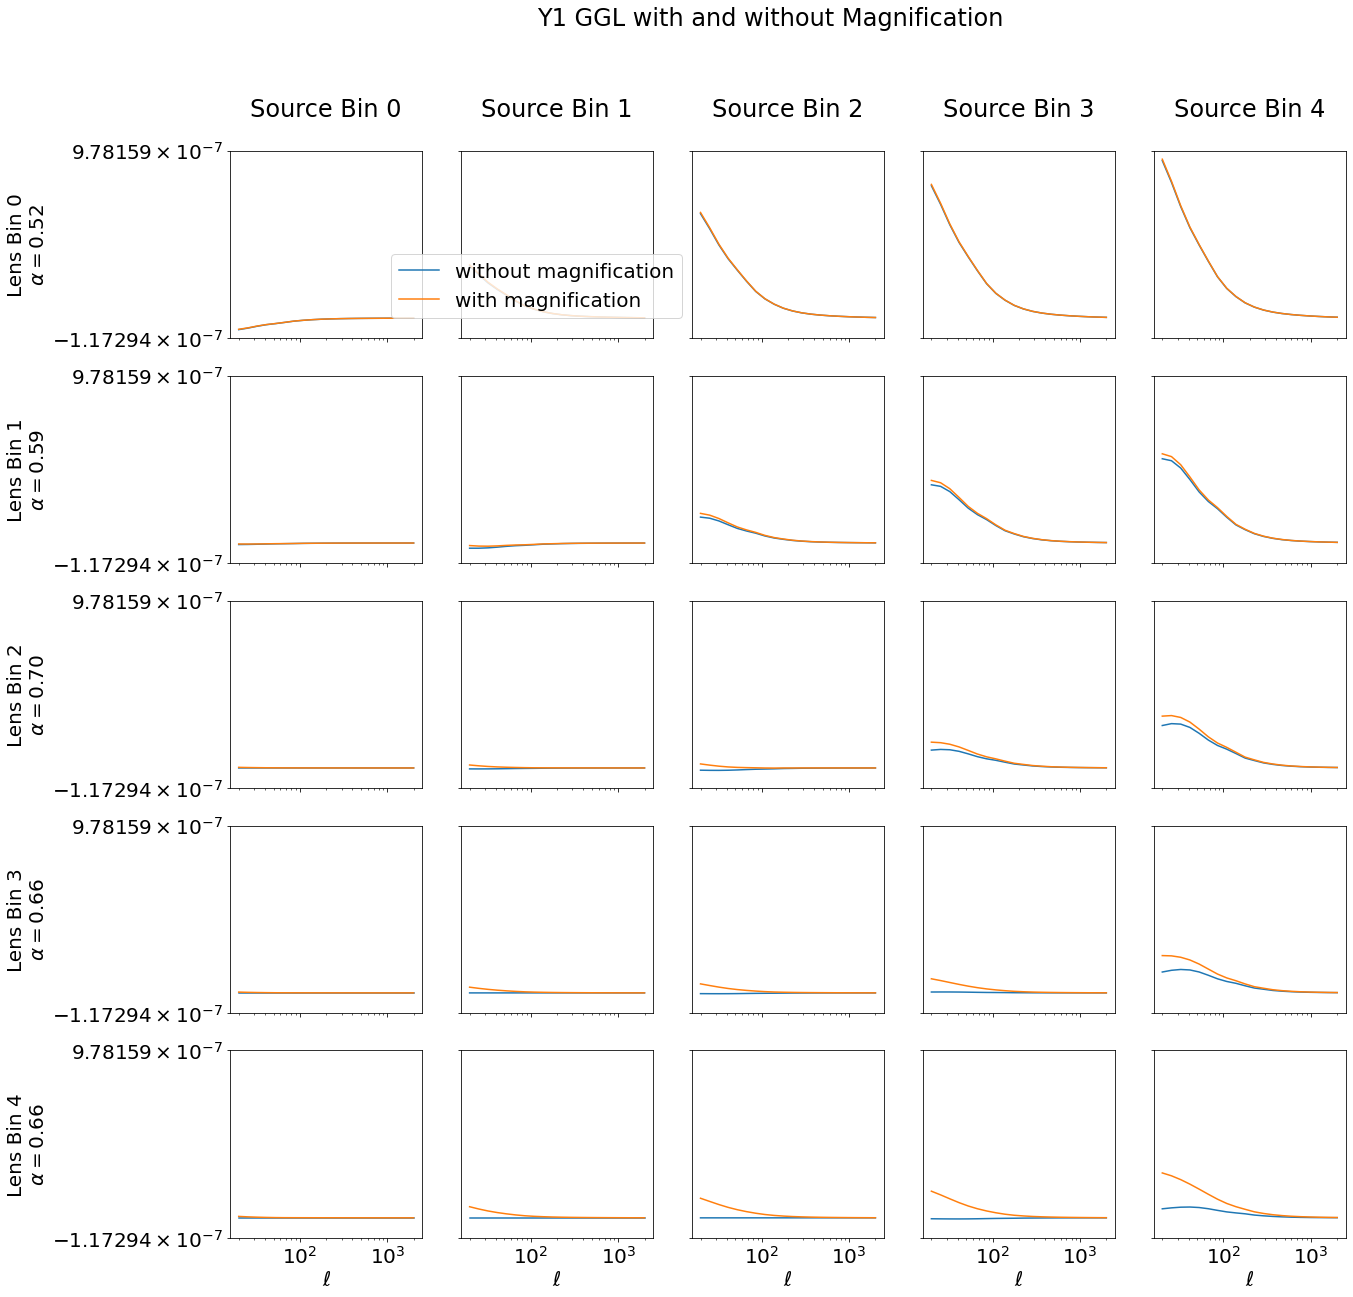

In [16]:
fig, axs = plt.subplots(5,5, figsize=(20,20), sharey=True, sharex=True)

for i,(lensbin, sourcebin) in enumerate(dvy1.get_correlation_pairs_all()["galaxy_galaxy_lensing"]):
    
    axs[lensbin, sourcebin].plot(dvy1.ells, ggl_y1_nomagbias.T[i], label=r"without magnification")
    axs[lensbin, sourcebin].plot(dvy1.ells, ggl_y1.T[i], 
                                 label=r"with magnification")

    axs[lensbin, sourcebin].set_yscale('symlog')
    axs[lensbin, sourcebin].set_xscale('log')
    

[a.set_ylabel('Lens Bin %i\n'%i+r"$\alpha = $"+"%.02f"%magbias_y10[i], fontsize=20) 
 for i,a in enumerate(axs[:,0])]
[a.set_xlabel(r'$\ell$') for i,a in enumerate(axs[-1])]
[a.set_title('Source Bin %i\n'%i ) for i,a in enumerate(axs[0])]

axs[0,2].legend(bbox_to_anchor=(0,0.5))
plt.suptitle('Y1 GGL with and without Magnification')

plt.show()

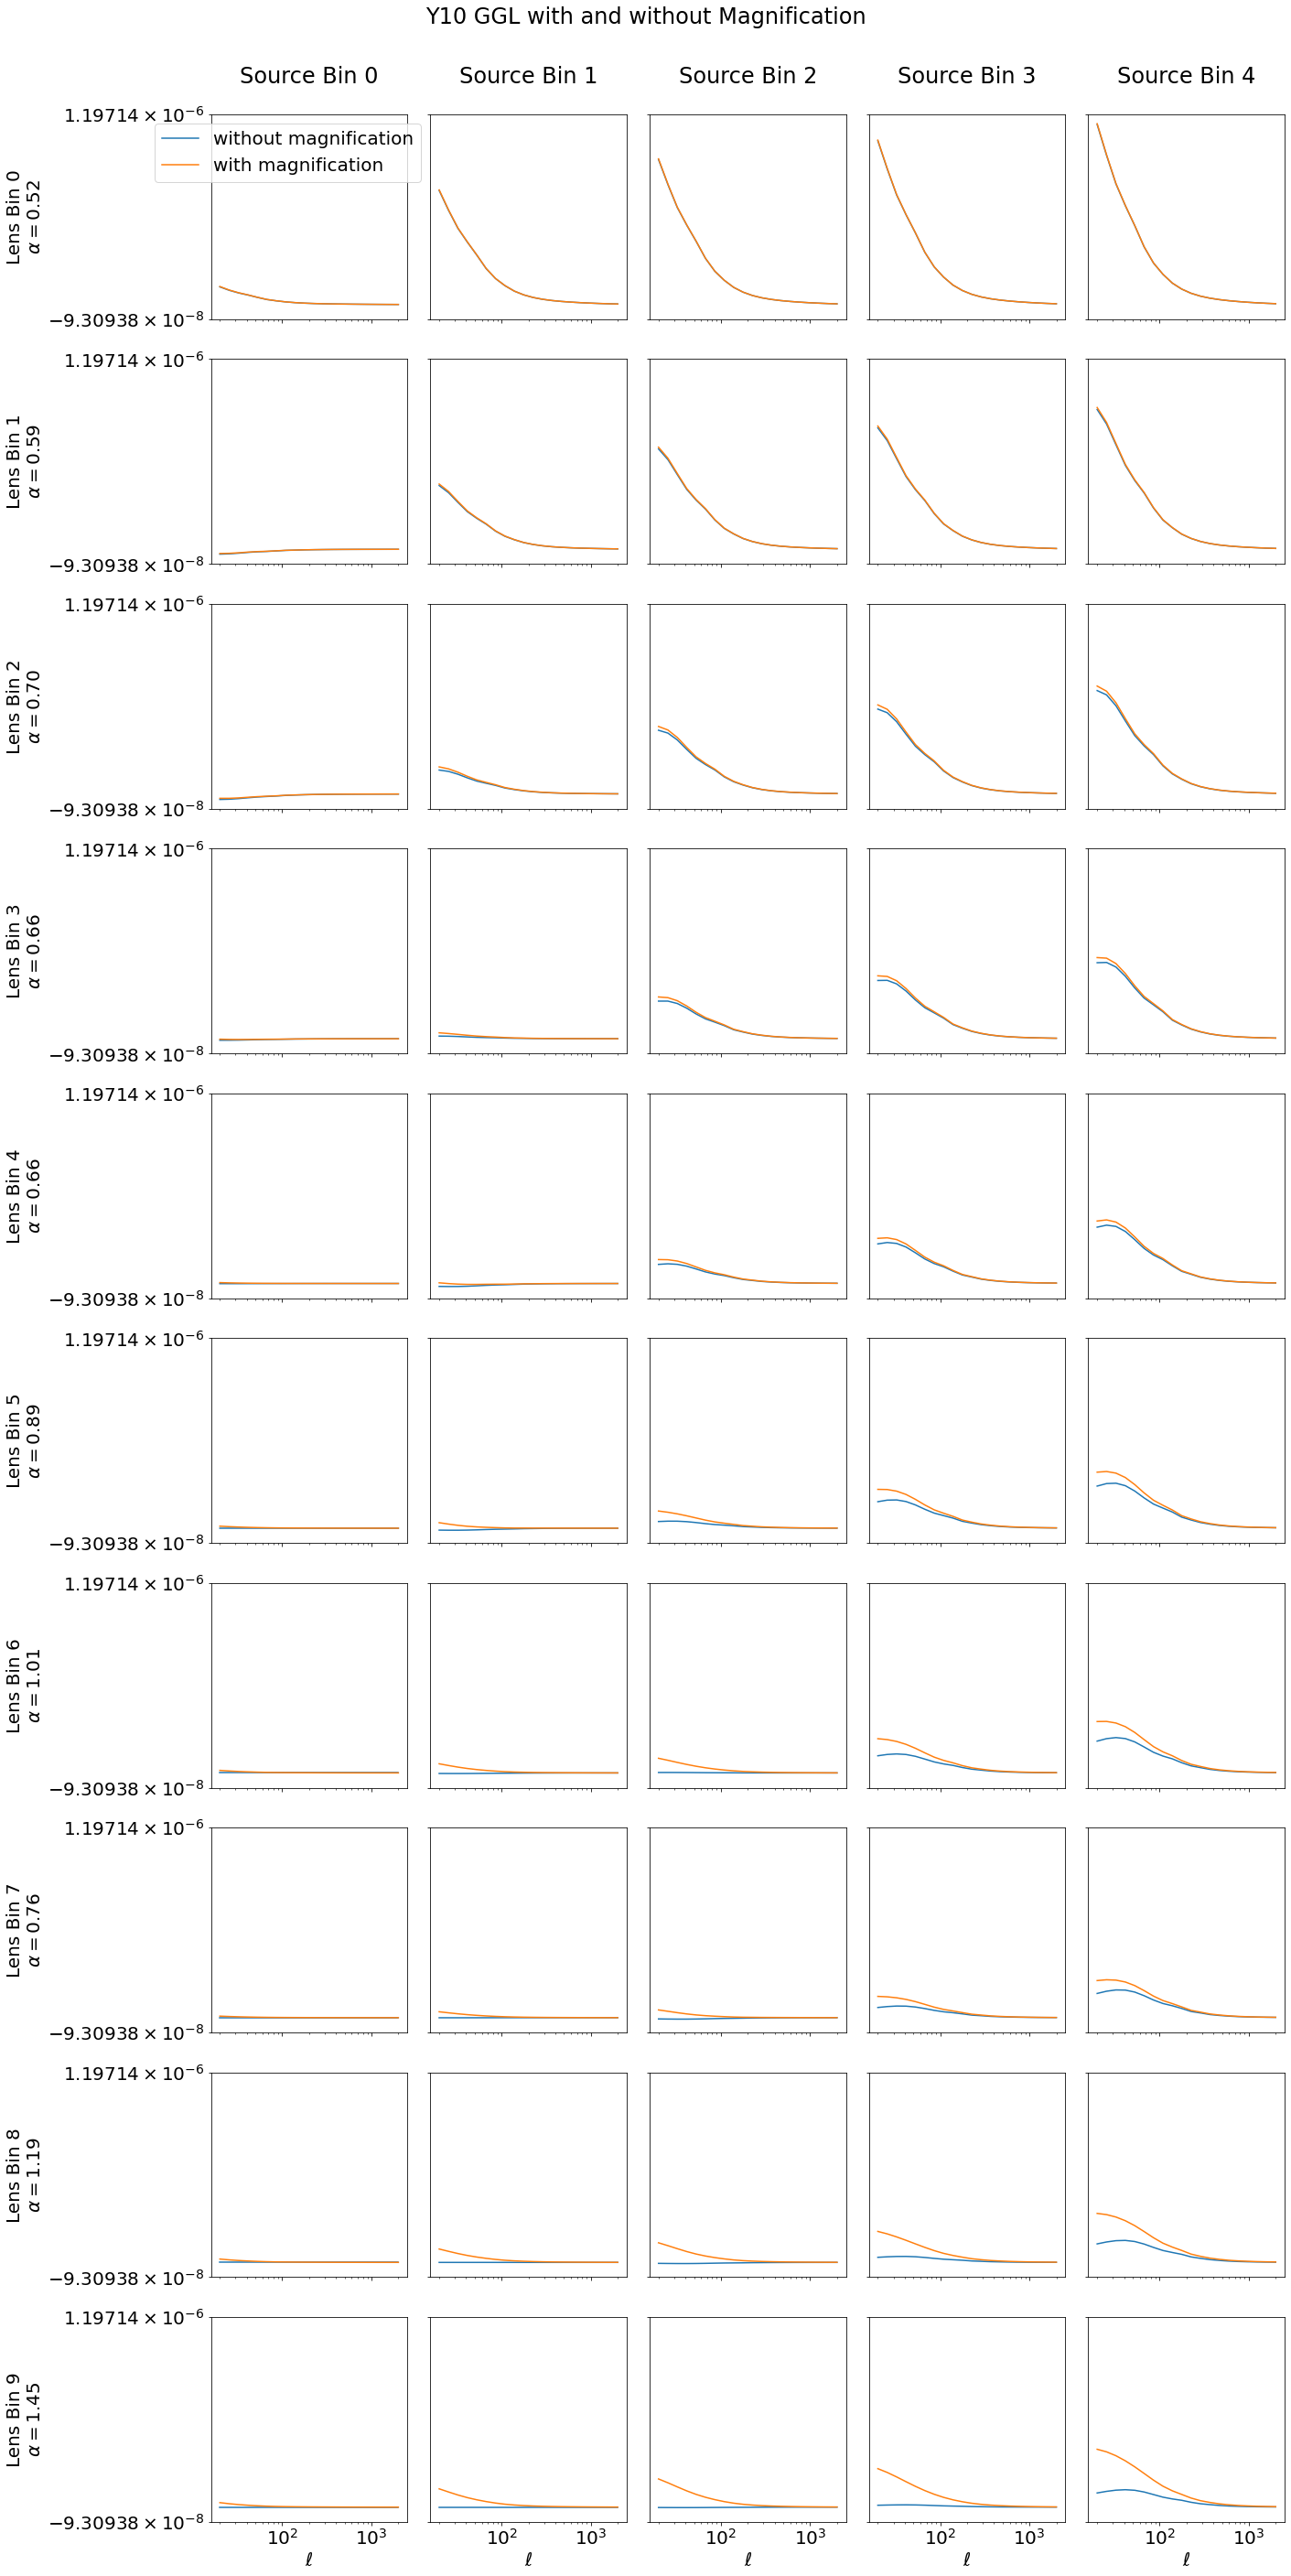

In [17]:
fig, axs = plt.subplots(10,5, figsize=(20,40), sharey=True, sharex=True)

for i,(lensbin, sourcebin) in enumerate(dvy10.get_correlation_pairs_all()["galaxy_galaxy_lensing"]):
    
    axs[lensbin, sourcebin].plot(dvy10.ells, ggl_y10_nomagbias.T[i], label=r"without magnification")
    axs[lensbin, sourcebin].plot(dvy10.ells, ggl_y10.T[i], 
                                 label=r"with magnification")

    axs[lensbin, sourcebin].set_yscale('symlog')
    axs[lensbin, sourcebin].set_xscale('log')
    

[a.set_ylabel('Lens Bin %i\n'%i+r"$\alpha = $"+"%.02f"%magbias_y10[i], fontsize=20) 
 for i,a in enumerate(axs[:,0])]
[a.set_xlabel(r'$\ell$') for i,a in enumerate(axs[-1])]
[a.set_title('Source Bin %i\n'%i) for i,a in enumerate(axs[0])]
plt.suptitle('Y10 GGL with and without Magnification\n\n')

fig.tight_layout()

axs[0,1].legend(bbox_to_anchor=(0,1))

plt.show()